# Notebook Objectives

 - Handle Data that is across different experiments (numbers of latents)
 - Nominally these are:
    - PLotting of loss as a function of latent dimension
    - Creating super trajectories for making movies of reconstruction

In [1]:
import json, os, jax, glob
import jax.numpy as jnp
import mdtraj as md
import matplotlib.pyplot as plt
import numpy as np
from pyscripts.analysis import NN_Experiment_Analyzer, ND_NN_Experiment_Analyzer
#import pyscripts.jax_amber3 as jaa

jax:    0.5.0
jaxlib: 0.5.0
numpy:  1.26.4
python: 3.12.8 | packaged by conda-forge | (main, Dec  5 2024, 14:24:40) [GCC 13.3.0]
device info: NVIDIA A100-SXM4-40GB-1, 1 local devices"
process_count: 1
platform: uname_result(system='Linux', node='joseph-xl-gpu', release='6.11.0-17-generic', version='#17~24.04.2-Ubuntu SMP PREEMPT_DYNAMIC Mon Jan 20 22:48:29 UTC 2', machine='x86_64')


$ nvidia-smi
Fri Feb 21 22:17:49 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.120                Driver Version: 550.120        CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|===============

In [2]:
def atom_rmsd(a, b, potential_coefficient=None): # for arrays of (n_conf, n_atom*3)
    mn = a.shape[-1]//3
    x_inds, y_inds, z_inds = jnp.arange(0,mn), jnp.arange(mn, 2*mn), jnp.arange(2*mn, 3*mn)
    return jnp.sqrt(jnp.mean((b[x_inds] - a[x_inds])**2 + (b[y_inds] - a[y_inds])**2 + (b[z_inds] - a[z_inds])**2))

#gas_fun, _ = jaa.get_amber_functions('Simulation/ala_deca_peptide.prmtop')
def scaled_pot_enr_diff(a, b, potential_coefficient=None): # WITH A AS BATCH AND B AS RECON
    return ((gas_fun(a) - gas_fun(b))/gas_fun(a))**2 #Unitless quantity

class NN_Multi_Analyzer():
    def __init__(self, json_params_series:[dict], netcdf_fns:[str], checkpoint_dirs:[str], analyzer=NN_Experiment_Analyzer):
        assert len(json_fns) == len(netcdf_fns)
        assert len(json_fns) == len(checkpoint_dirs)

        self.experiments = {}

        for i in range(len(netcdf_fns)):
            exp = analyzer(json_params_series[i], netcdf_fns[i], checkpoint_dirs[i])
            key = f"{exp.n_latents} Latents"
            self.experiments[key] = exp

    def super_traj_construct(self, rng_seed, n_frames=500, mode='Decoded', num_components=None):
        """
        Creates two trajectories, which can be simultaneously visualized to see reconstruction with different numbers of latents

        Parameters:
            n_frames: The number of frames from each set to use, will be a slice of every x frames of the test data such that there are n_frames
                      i.e. if test_data is size 2000, and 500 frames are requested, every fourth frame of the test set will be shown
            mode: string in ['Decoded', 'Modeled'] : If Decoded, the super traj will contain frames that were encoded and decoded by the NN
                                                     If Modeled, the super traj will contain frames generated by GMM
            num_components: if not None, must be a list of integers the same length as the number of experiments
                            Will generate samples from the Gaussian Mixture Model to compare to
        """
        assert mode in ['Decoded', 'Modeled']
        #Since all experiments should have the same numbers of dimensions in this analysis, the atomistic size will be obtained from only one
        #size_test_set = pass
        num_experiments = len(self.experiments)
        if mode == 'Modeled':
            assert num_components is not None
            assert type(num_components) == list
            assert len(num_components) == num_experiments
            assert False not in [type(num) == int for num in num_components]
        num_test_set, num_dimensions = list(self.experiments.values())[0].test_data.shape
        #print(num_test_set, num_dimensions)
        assert num_test_set % n_frames == 0
        super_traj_test = jnp.zeros((n_frames*num_experiments, num_dimensions))
        super_traj_comp = jnp.zeros((n_frames*num_experiments, num_dimensions))

        for i in range(num_experiments):
            indices = jnp.arange(0, num_test_set, num_test_set//n_frames)
            #print(indices.shape)
            #print(indices)
            test_data = list(self.experiments.values())[i].test_data
            super_traj_test = super_traj_test.at[i*n_frames:(i+1)*n_frames, :].set(test_data[indices, :])

            if mode == 'Decoded':
                comp_data, _ = list(self.experiments.values())[i].operate(rng_seed)
            elif mode == 'Modeled':
                _, comp_data = list(self.experiments.values())[i].gaussian_mm_fit(rng_seed, num_components[i])

            super_traj_comp = super_traj_comp.at[i*n_frames:(i+1)*n_frames, :].set(comp_data[indices, :])

        assert not jnp.any(super_traj_comp == 0.0) and not jnp.any(super_traj_test == 0.0)
        return super_traj_test, super_traj_comp

    def rmsd_violin_plot(self, rng_seed, title):
        #Assemble the Data
        latents, rmsds = [], []
        for key, exp in self.experiments.items():
            latents.append(exp.n_latents)
            recon, _ = exp.operate(rng_seed)
            rmsds.append(jax.vmap(atom_rmsd)(exp.test_data, recon))
        latents, rmsds = jnp.array(latents), jnp.array(rmsds)
        pos = jnp.log(latents) / jnp.log(2)
        #Make the Violin PLot
        plt.clf()
        figure(figsize=(3.25, 3), dpi=80)
        plt.rc('font', **{'family' : 'normal', 'weight' : 'bold', 'size'   : 11})
        parts = plt.violinplot(rmsds*10, pos, showmeans=True, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_edgecolor('black')
            pc.set_alpha(1)
        plt.title(title)
        plt.ylabel('RMSD (Angstrom)')
        plt.xlabel('Num Latents (log base 2)')
        plt.show()

    def potential_violin_plot(self, rng_seed, title):
        #Assemble the Data
        latents, pots = [], []
        for key, exp in self.experiments.items():
            latents.append(exp.n_latents)
            recon, _ = exp.operate(rng_seed)
            pots.append(jax.jit(scaled_pot_enr_diff)(exp.test_data, recon))
        latents, pots = jnp.array(latents), jnp.array(pots)
        pos = jnp.log(latents) / jnp.log(2)
        #Make the Violin PLot
        plt.clf()
        parts = plt.violinplot(jnp.sqrt(pots), pos, showmeans=True, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_edgecolor('black')
            pc.set_alpha(1)
        plt.title(title)
        plt.ylabel('Potential Deviation (%)')
        plt.yscale('log')
        plt.xlabel('Num Latents (log base 2)')
        plt.show()
            
        

In [3]:
rpt = 0
darmsd_cards = [f'/media/volume/Josephs-Volume/previous_data/4_24_24/jsons/DA*{rpt}.json',
                f'/media/volume/Josephs-Volume/previous_data/4_24_24/DA_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
                f'/media/volume/Josephs-Volume/previous_data/4_24_24/DA_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']

crrmsd_cards = [f'/media/volume/Josephs-Volume/previous_data/4_24_24/jsons/Crambin_AE_*{rpt}.json',
                f'/media/volume/Josephs-Volume/previous_data/4_24_24/Crambin_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
                f'/media/volume/Josephs-Volume/previous_data/4_24_24/Crambin_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default']

bromo_cards = [f'/media/volume/Josephs-Volume/previous_data/5_20_24/3mxf_*{rpt}.json',
               f'/media/volume/Josephs-Volume/previous_data/5_20_24/3mxf_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
               f'/media/volume/Josephs-Volume/previous_data/5_20_24/3mxf_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']


wd_cards = bromo_cards
system = 'Bromodomains RMSD-Only'

In [4]:
#No Updates necessary below this line to change systems
json_wildcard, nc_wildcard, ckpt_wildcard = wd_cards

json_fns = sorted(glob.glob(json_wildcard))
netcdf_fns = sorted(glob.glob(nc_wildcard))
all_checkpoint_dirs = sorted(glob.glob(ckpt_wildcard))

checkpoint_dirs = []
#Two checkpoints per model, always take the latest one
indices = range(1, len(all_checkpoint_dirs)+1, 2)
for ind in indices:
    checkpoint_dirs.append(all_checkpoint_dirs[ind])

assert len(json_fns) == len(netcdf_fns)
assert len(json_fns) == len(checkpoint_dirs)

In [5]:
# rpt = 1
# bromo_cards = [f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/5_20_24/jsons/3mxf_*{rpt}.json',
#                f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/5_20_24/3mxf_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
#                f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/5_20_24/3mxf_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']
# dapot_cards = [f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/5_15_24/jsons/*{rpt}.json',
#                f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/*_latents/rpt_{rpt}/*checkpoint.nc',
#                f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/5_15_24/DA_AE_Dropout_RMSD_and_Scale/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']
# darmsd_cards = [f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/4_24_24/jsons/DA*{rpt}.json',
#                 f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/4_24_24/DA_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
#                 f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/4_24_24/DA_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']
# crrmsd_cards = [f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/4_24_24/jsons/Crambin_AE_*{rpt}.json',
#                 f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/4_24_24/Crambin_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
#                 f'/media/volume/Joseph-Large/githubs/Deep-MMS/bridges2_runs/4_24_24/Crambin_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default']
# HIV1p_cards = [f'HIV1p_AE_Dropout_RMSD_only/jsons/*{rpt}.json',
#                f'HIV1p_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
#                f'HIV1p_AE_Dropout_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']
# oxy_cards = [f'/media/volume/Aryan-s-Volume/Deep-MMS/bridges2_runs/Oxycodone_RMSD_only/*{rpt}.json',
#              f'/media/volume/Aryan-s-Volume/Deep-MMS/bridges2_runs/Oxycodone_RMSD_only/*_latents/rpt_{rpt}/*checkpoint.nc',
#              f'/media/volume/Aryan-s-Volume/Deep-MMS/bridges2_runs/Oxycodone_RMSD_only/*_latents/rpt_{rpt}/checkpoint_managed/*/default']
# da_noDrop_rmsd_cards = [f'/media/volume/Joseph-Large2/githubs/Deep-MMS/DA_AE_NO-Dropout_RMSD/*{rpt}.json',
#                         f'/media/volume/Joseph-Large2/githubs/Deep-MMS/DA_AE_NO-Dropout_RMSD/*_latents/rpt_{rpt}/*checkpoint.nc',
#                         f'/media/volume/Joseph-Large2/githubs/Deep-MMS/DA_AE_NO-Dropout_RMSD/*_latents/rpt_{rpt}/checkpoint_managed/*/default/']

# #Use the following rpt for each, respectively, 3, 0, 0, 0, 0, 0, 1, 


# json_wildcard, nc_wildcard, ckpt_wildcard = da_noDrop_rmsd_cards
# system = 'Deca-Alanine No-Dropouts'



# json_fns = sorted(glob.glob(json_wildcard))
# netcdf_fns = sorted(glob.glob(nc_wildcard))
# all_checkpoint_dirs = sorted(glob.glob(ckpt_wildcard))

# checkpoint_dirs = []
# #Two checkpoints per model, always take the latest one
# indices = range(1, len(all_checkpoint_dirs)+1, 2)
# for ind in indices:
#     checkpoint_dirs.append(all_checkpoint_dirs[ind])

# assert len(json_fns) == len(netcdf_fns)
# assert len(json_fns) == len(checkpoint_dirs)

In [6]:
for i in range(len(json_fns)):
    print(json_fns[i])
    print(netcdf_fns[i])
    print(checkpoint_dirs[i])
    print('#########################################################')

/media/volume/Josephs-Volume/previous_data/5_20_24/3mxf_AE_Dropout_RMSD_only_0001_0.json
/media/volume/Josephs-Volume/previous_data/5_20_24/3mxf_AE_Dropout_RMSD_only/0001_latents/rpt_0/model_3mxf_AE_Dropout_RMSD_only_0001_checkpoint.nc
/media/volume/Josephs-Volume/previous_data/5_20_24/3mxf_AE_Dropout_RMSD_only/0001_latents/rpt_0/checkpoint_managed/800/default/
#########################################################
/media/volume/Josephs-Volume/previous_data/5_20_24/3mxf_AE_Dropout_RMSD_only_0002_0.json
/media/volume/Josephs-Volume/previous_data/5_20_24/3mxf_AE_Dropout_RMSD_only/0002_latents/rpt_0/model_3mxf_AE_Dropout_RMSD_only_0002_checkpoint.nc
/media/volume/Josephs-Volume/previous_data/5_20_24/3mxf_AE_Dropout_RMSD_only/0002_latents/rpt_0/checkpoint_managed/800/default/
#########################################################
/media/volume/Josephs-Volume/previous_data/5_20_24/3mxf_AE_Dropout_RMSD_only_0004_0.json
/media/volume/Josephs-Volume/previous_data/5_20_24/3mxf_AE_Dropout_

In [7]:
json_params_series = []

for json_fn in json_fns:
    #Json files were on Bridges2, doctor for this analysis
    with open(json_fn, 'r') as f:
        json_params = json.load(f)
    #print(json_params)
    #the json is from bridges, change file paths to be from jetstream
    #/ocean/projects/mcb160011p/josephdb/githubs/Deep-MMS/ -> /media/volume/sdb/githubs/Deep-MMS/
    for key in ["fname_dcd", "fname_prmtop", "save_dir"]:
        json_params[key] = json_params[key].replace("/ocean/projects/mcb160011p/josephdb/",
                                                    "/media/volume/Josephs-Volume/")
        json_params[key] = json_params[key].replace("/ocean/projects/mcb160011p/abahl/",
                                                    "/media/volume/Aryan-s-Volume/")
        #print(os.path.isfile(json_params[key]))
    #print(json_params)
    json_params_series.append(json_params)

In [8]:
self = NN_Multi_Analyzer(json_params_series, netcdf_fns, checkpoint_dirs, analyzer=NN_Experiment_Analyzer)

Load Files
{'fname_dcd': '/media/volume/Josephs-Volume/githubs/Deep-MMS/Simulation/3mxf_split2.dcd', 'fname_prmtop': '/media/volume/Josephs-Volume/githubs/Deep-MMS/Simulation/3mxf_protein_ligand.pdb', 'fname_pdb': '/ocean/projects/mcb160011p/josephdb/githubs/Deep-MMS/Simulation/3mxf_protein_ligand.pdb', 'save_dir': '/media/volume/Josephs-Volume/githubs/Deep-MMS/', 'data_dir': 'None', 'max_epoch': 100000, 'latent_dim': 1, 'test_slice': 0, 'data_slice_start': 0, 'data_slice_end': 'None', 'model_name': '3mxf_AE_Dropout_RMSD_only', 'batch_size': 2000, 'learning_rate': 1e-06, 'dropout_rates': [0.1, 0.1, 0.1], 'potential_threshold': 10, 'model_type': 'AE', 'coordinate_scheme': 'Cartesian', 'resume_latest': False, 'report_potential': False, 'checkpoint_interval': 200}
Load Data with MDTraj
Batch data
(8000, 6531) (2000, 6531)
Model Init
Batch Data
Read NetCDF and Checkpoint
Load Files
{'fname_dcd': '/media/volume/Josephs-Volume/githubs/Deep-MMS/Simulation/3mxf_split2.dcd', 'fname_prmtop': '/m

In [ ]:
def plot_results(exp):
    traingrp = exp.rootgrp['Train']
    testgrp = exp.rootgrp['Test']
    keys = ['RMSD']
    plt.clf()
    plt.title('RMSD' + f' {exp.n_latents} Latents')
    for grp in [traingrp, testgrp]:
        _ = plt.plot(np.arange(grp.variables['RMSD'][:, :].shape[0]),
                     np.mean(grp.variables['RMSD'][:, :], axis=1))
    plt.xlabel('Epoch')
    plt.ylabel('RMSD (nm)')
    plt.legend(['Train','Test'])
    plt.show()

    print(f'Num Epochs {traingrp.variables['RMSD'][:, :].shape[0]}')
    print(f'Last RMSD (nm): Train: {np.mean(traingrp.variables['RMSD'][-1, :])} Test {np.mean(testgrp.variables['RMSD'][-1, :])}')

In [ ]:
for key, exp in self.experiments.items():
    print(key, exp.model)

In [ ]:
for key, exp in self.experiments.items():
    print(key, exp)
    exp.plot_results()

In [ ]:
def rmsd_violin_plot(self, rng_seed, title):
    #Assemble the Data
    latents, rmsds = [], []
    for key, exp in self.experiments.items():
        print(key)
        latents.append(exp.n_latents)
        recon, _ = exp.operate(rng_seed)
        rmsds.append(jax.vmap(atom_rmsd)(exp.test_data, recon))
    latents, rmsds = jnp.array(latents), jnp.array(rmsds)
    pos = jnp.log(latents) / jnp.log(2)
    #Make the Violin PLot
    plt.clf()
    plt.figure(figsize=(3.25, 3), dpi=80)
    plt.rc('font', **{'weight':'normal', 'size':11})
    parts = plt.violinplot(rmsds*10, pos, showmeans=True, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_edgecolor('black')
        pc.set_alpha(1)
    plt.title(title)
    plt.ylabel('RMSD (Angstrom)')
    plt.xlabel('Num Latents (log base 2)')
    plt.xticks(pos[pos % 2 == 0])
    plt.savefig(f'{title}.png', dpi=600, bbox_inches = "tight")
    plt.show()

In [ ]:
rmsd_violin_plot(self, rng_seed=98263, title=f'RMSD Error - {system}')

In [ ]:
for key, exp in self.experiments.items():
    print(key, 'ran for:', len(exp.rootgrp['Train'].dimensions['epoch']), 'epochs')

In [ ]:
def last_epoch_plot(self, title):
    #Assemble the Data
    latents, epochs = [], []
    for key, exp in self.experiments.items():
        latents.append(exp.n_latents)
        epochs.append(len(exp.rootgrp['Train'].dimensions['epoch']))
    latents, epochs = jnp.array(latents), jnp.array(epochs)
    pos = jnp.log(latents) / jnp.log(2)
    #Make the Violin PLot
    plt.clf()
    plt.figure(figsize=(3.25, 3), dpi=80)
    plt.rc('font', **{'weight':'normal', 'size':11})
    plt.scatter(pos, epochs/1000)
    plt.title(title)
    plt.ylabel('Last Epoch Reached (10\u00B3)')
    plt.xlabel('Num Latents (log base 2)')
    plt.xticks(pos[pos % 2 == 0])
    plt.savefig(f'{title}.png', dpi=600, bbox_inches = "tight")
    plt.show()

In [ ]:
last_epoch_plot(self, f'Length of Training - {system}')

#### Clustering Accuracy

Assign "True" labels by clustering the test set data in the atomistic space\
Then assign predicted labels for each of PCA and Encoding for each of Latents

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, HDBSCAN
from sklearn.metrics import rand_score, normalized_mutual_info_score, fowlkes_mallows_score
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from datetime import datetime

decode_pca = lambda data, pca: np.matmul(data, np.matmul(pca.components_.T, pca.components_)) + pca.mean_

In [10]:
#Get test frames
test_frames = self.experiments['2 Latents'].test_data
assert False not in [jnp.all(self.experiments['2 Latents'].test_data == self.experiments[key].test_data) for key in self.experiments.keys()]

#Get distance matrix of the test frames
def dist_matrix_row(a, bs):
    return jax.vmap(atom_rmsd, in_axes=(None, 0))(a, bs)

def rmsd_distance_matrix(frames):
    dist_mat = jnp.empty((frames.shape[0], frames.shape[0]))
    for i in range(test_frames.shape[0]):
        dist_mat = dist_mat.at[i].set(dist_matrix_row(test_frames[i], test_frames))
    return dist_mat

test_distance_matrix = rmsd_distance_matrix(test_frames)

In [11]:
start = datetime.now()
labels_Kmeans = KMeans(n_clusters=6).fit_predict(test_frames)
check1 = datetime.now()
print(f"Time for Kmeans was {check1 - start}")
labels_Agg = AgglomerativeClustering(n_clusters=6, metric='precomputed', linkage='complete').fit_predict(test_distance_matrix)
check2 = datetime.now()
print(f"Time for Agglomerative was {check2 - check1}")
labels_HDB = HDBSCAN(metric='precomputed').fit_predict(test_distance_matrix)
check3 = datetime.now()
print(f"Time for HDBScan was {check3 - check2}")

Time for Kmeans was 0:00:00.459199
Time for Agglomerative was 0:00:00.117506
Time for HDBScan was 0:00:00.140743


In [12]:
hdbscan_epsilons = np.linspace(0, test_distance_matrix.max())

In [13]:
#Entries {key=name, value=clustering_method}
clustering_methods = {'KMeans': KMeans,
                      'Agglomerative': AgglomerativeClustering,
                      'HDBScan': HDBSCAN}
methods_without_nums_clusters = ['HDBScan']

#Entries {key=name, value=[function, is_supervised]}
metric_functions = {"Rand Score":[rand_score, True],
                    "normalized MI Score":[normalized_mutual_info_score, True],
                    "Fowlkes-Mallows Score":[fowlkes_mallows_score, True],
                    "Silhouette Score":[silhouette_score, False],
                    "Davies-Bouldin Score":[davies_bouldin_score, False],
                    "Calinksi-Harabasz Score":[calinski_harabasz_score, False]}


def num_clusters_by_method(method_name, min_clusters=2, max_clusters=40, num_repetitions=5, plot=False):
    assert method_name in clustering_methods.keys()
    
    sil_scores = np.empty((num_repetitions, 1+max_clusters-min_clusters))
    nums_clusters = np.arange(min_clusters, max_clusters+1)
    for j in range(num_repetitions):
        if method_name == 'KMeans':
             #Iterate over number of clusters
            for i in range(min_clusters, max_clusters+1):
                labels = clustering_methods[method_name](n_clusters=i).fit_predict(test_frames)
                sil_scores[j, i-min_clusters] = silhouette_score(test_frames, labels)
        
        elif method_name == 'Agglomerative':
             #Iterate over number of clusters
            for i in range(min_clusters, max_clusters+1):
                labels = clustering_methods[method_name](n_clusters=i, metric='precomputed', linkage='complete').fit_predict(test_distance_matrix)
                sil_scores[j, i-min_clusters] = silhouette_score(test_frames, labels)
        
        elif method_name == 'HDBScan':
             #Iterate over threshold
            for i, k in enumerate(range(min_clusters, max_clusters+1)):
                eps = hdbscan_epsilons[i]
                labels = HDBSCAN(metric='precomputed', cluster_selection_epsilon=eps).fit_predict(test_distance_matrix)
                sil_scores[j, i-min_clusters] = silhouette_score(test_frames, labels)
        

    if plot is True:
        plt.clf()
        if method_name in ['KMeans', 'Agglomerative']:
            _ = plt.errorbar(x=nums_clusters, y=np.mean(sil_scores, axis=0), yerr=np.std(sil_scores, axis=0))
            plt.xlabel('Num Clusters')
        elif method_name in ['HDBScan']:
            _ = plt.errorbar(x=hdbscan_epsilons[:len(range(min_clusters, max_clusters+1))], y=np.mean(sil_scores, axis=0), yerr=np.std(sil_scores, axis=0))
            plt.xlabel('HDBScan Epsilon')
        plt.ylabel('Silhouette Score')
        plt.title(method_name)
        plt.savefig(f'clustering_figures/optimal_n_clusters_{system.replace(' ','_')}_{method_name}.png', dpi=900)
        plt.show()
            
    return np.argmax(np.mean(sil_scores, axis=0))+min_clusters

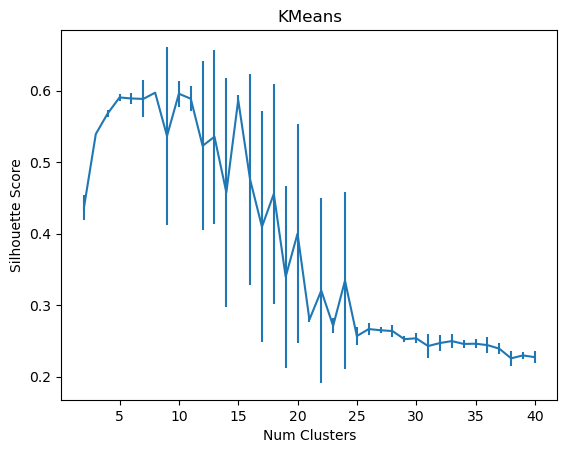

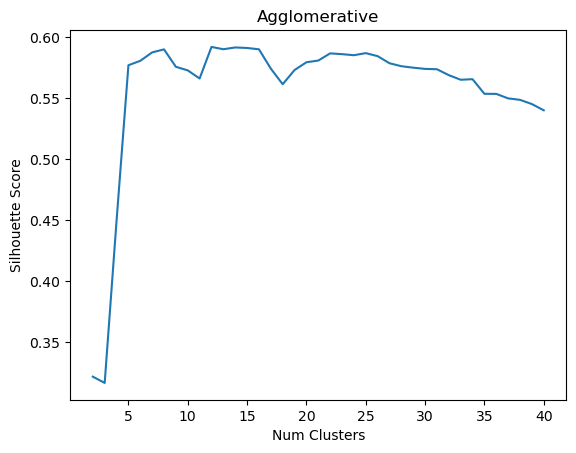

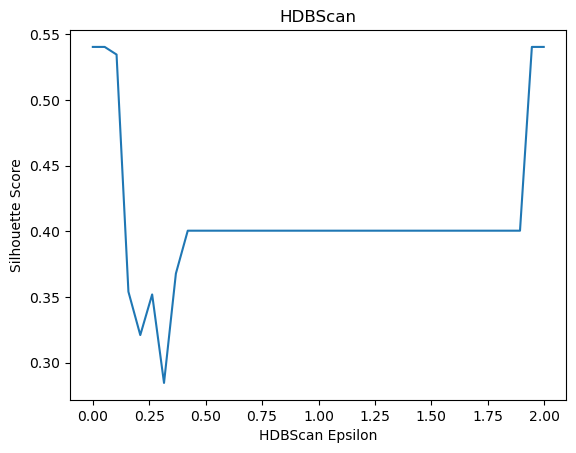

{'KMeans': 8, 'Agglomerative': 12, 'HDBScan': 2}


In [14]:
optimal_nums_clusters = {}

for key in clustering_methods.keys():
    optimal_nums_clusters[key] = num_clusters_by_method(key, plot=True)    
        
print(optimal_nums_clusters)

In [16]:
optimal_nums_clusters['HDBScan'] = None

In [17]:
#SUPERVISED
 #rand_score(labels_true, labels_pred)
 #normalized_mutual_info_score(labels_true, labels_pred)
 #fowlkes_mallows_score(labels_true, labels_pred)
#UNSUPERVISED
 #silhouette_score(X, labels)
 #davies_bouldin_score(X, labels)
 #calinski_harabasz_score(X, labels)

In [18]:
mean_error = lambda err_arr: np.sqrt(np.sum(err_arr**2)) / err_arr.shape[0]

def validation_value(n_clusters, clustering_method, metric_function, supervised=True):
    final = []
    for j in range(5):
        # Report rand score for repeated clusterings of the test data
        if method_name == 'KMeans':
            labels_true = clustering_methods[clustering_method](n_clusters=n_clusters).fit_predict(test_frames)
        elif method_name == 'Agglomerative':
            labels_true = clustering_methods[clustering_method](n_clusters=n_clusters, metric='precomputed', linkage='complete').fit_predict(test_distance_matrix)
        elif method_name == 'HDBScan':
            labels_true = clustering_methods[clustering_method](metric='precomputed').fit_predict(test_distance_matrix)
        else:
            raise Exception("How did that happen")
        
        validation_set = []
        for i in range(10):
            if method_name == 'KMeans':
                labels_pred = clustering_methods[clustering_method](n_clusters=n_clusters).fit_predict(test_frames)
            elif method_name == 'Agglomerative':
                labels_pred = clustering_methods[clustering_method](n_clusters=n_clusters, metric='precomputed', linkage='complete').fit_predict(test_distance_matrix)
            elif method_name == 'HDBScan':
                labels_pred = clustering_methods[clustering_method](metric='precomputed').fit_predict(test_distance_matrix)
            else:
                raise Exception("How did that happen")
                
            if supervised:
                #Compare labels_a to labels_b
                validation_set.append(metric_function(labels_true, labels_pred))
            else:
                #Compare samples and labels_b
                validation_set.append(metric_function(test_frames, labels_pred))
                
        final.append([np.mean(validation_set), np.std(validation_set)])

    final = np.array(final)
    final = (np.mean(final[:, 0]), mean_error(final[:, 1]))
    return final

def evaluate_pca_encoder_against_metric(n_clusters, clustering_method, metric_function,
                                        rng_seed=2358, num_repetitions=5, supervised=True, recon_data=False):
    domain = np.array([exp.n_latents for key, exp in self.experiments.items()])
    pca_scores = np.empty((num_repetitions, domain.shape[0]))
    enc_scores = np.empty((num_repetitions, domain.shape[0]))

    for i in range(num_repetitions):
        if method_name == 'KMeans':
            labels_true = clustering_methods[clustering_method](n_clusters=n_clusters).fit_predict(test_frames)
        elif method_name == 'Agglomerative':
            labels_true = clustering_methods[clustering_method](n_clusters=n_clusters, metric='precomputed', linkage='complete').fit_predict(test_distance_matrix)
        elif method_name == 'HDBScan':
            labels_true = clustering_methods[clustering_method](metric='precomputed').fit_predict(test_distance_matrix)
        else:
            raise Exception("How did that happen")
        
        
        for key, exp in self.experiments.items():
            # Perform PCA "encoding" on test data
            if exp.n_latents < 2000:
                pca = PCA(n_components=exp.n_latents)
            else:
                pca = PCA(n_components=2000)
            pca_latents = pca.fit_transform(exp.test_data)

            if recon_data:
                # Perform Encoding and decoding on test data
                enc_latents, _ = exp.operate(rng_seed=rng_seed)
                #And project pca back to atomistic
                pca_latents = decode_pca(exp.test_data, pca)
            else:
                #Perform encoding only
                _, enc_latents = exp.operate(rng_seed=rng_seed)
            
            #Cluster both
            if method_name == 'KMeans':
                pca_labels = clustering_methods[clustering_method](n_clusters=n_clusters).fit_predict(pca_latents)
                enc_labels = clustering_methods[clustering_method](n_clusters=n_clusters).fit_predict(enc_latents)
            elif method_name == 'Agglomerative':
                pca_labels = clustering_methods[clustering_method](n_clusters=n_clusters, linkage='complete').fit_predict(pca_latents)
                enc_labels = clustering_methods[clustering_method](n_clusters=n_clusters, linkage='complete').fit_predict(enc_latents)
            elif method_name == 'HDBScan':
                pca_labels = clustering_methods[clustering_method]().fit_predict(pca_latents)
                enc_labels = clustering_methods[clustering_method]().fit_predict(enc_latents)
            else:
                raise Exception("How did that happen")

            if supervised:
                pca_scores[i, np.where(domain == exp.n_latents)] = metric_function(labels_true, pca_labels)
                enc_scores[i, np.where(domain == exp.n_latents)] = metric_function(labels_true, enc_labels)
            else:
                pca_scores[i, np.where(domain == exp.n_latents)] = metric_function(pca_latents, pca_labels)
                enc_scores[i, np.where(domain == exp.n_latents)] = metric_function(enc_latents, enc_labels)
            rng_seed += 1
    
    return domain, pca_scores, enc_scores

def clustering_metric_plot(xs, pcays, encys,
                           valid_y, valid_y_err,
                           n_clusters, title,
                           ylabel, xlabel='Number of Components (log base 2)'):
    
    plt.clf()
    plt.hlines(y=[valid_y, valid_y+valid_y_err, valid_y-valid_y_err],
               xmin=np.log2(xs).min() - 0.25, xmax=np.log2(xs).max() + 0.25,
               colors='black', alpha=[0.5, 0.3, 0.3],
               linestyles=['solid', 'dashed', 'dashed'])
    
    _ = plt.errorbar(x=np.log2(xs),
                     y=np.mean(pcays, axis=0),
                     yerr=np.std(pcays, axis=0), label='PCA')
    
    _ = plt.errorbar(x=np.log2(xs)+0.05,
                     y=np.mean(encys, axis=0),
                     yerr=np.std(encys, axis=0), label='Encoder')
    
    plt.legend()
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    if ylabel == 'Calinksi-Harabasz Score':
        plt.yscale('log')
    save_fn = f"clustering_figures/{system.replace(' ', '_')}_{ylabel.replace(' ', '_')}_{title.replace(' ', '_')}.png"
    plt.savefig(save_fn, dpi=900)
    plt.show()

KMeans Rand Score True


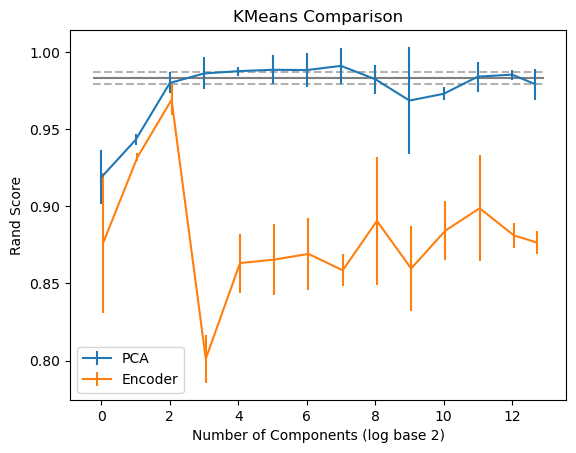

KMeans normalized MI Score True


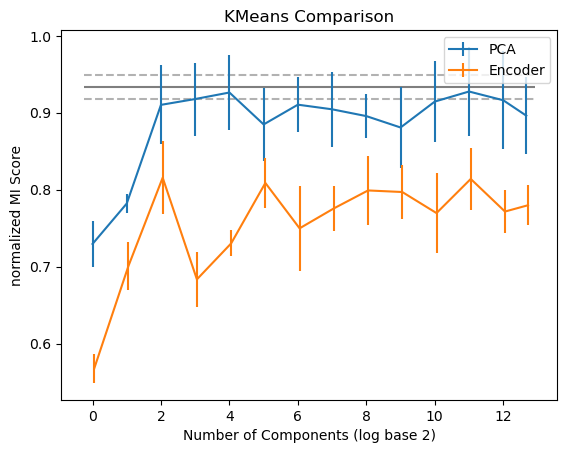

KMeans Fowlkes-Mallows Score True


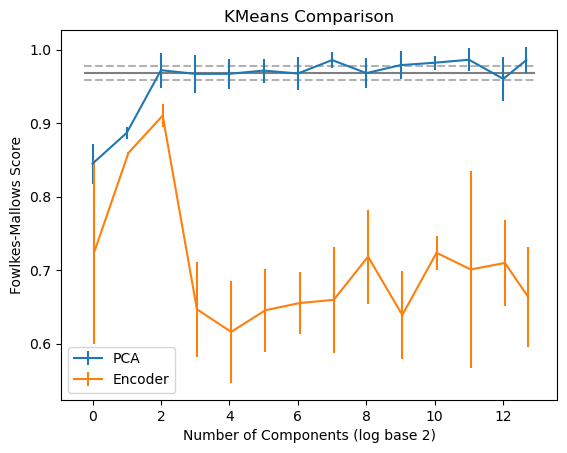

KMeans Silhouette Score False


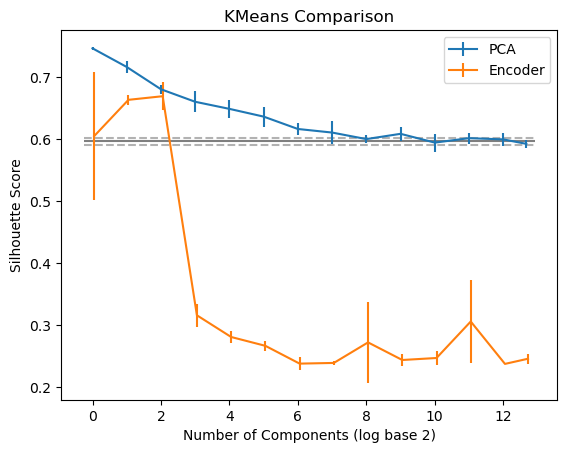

KMeans Davies-Bouldin Score False


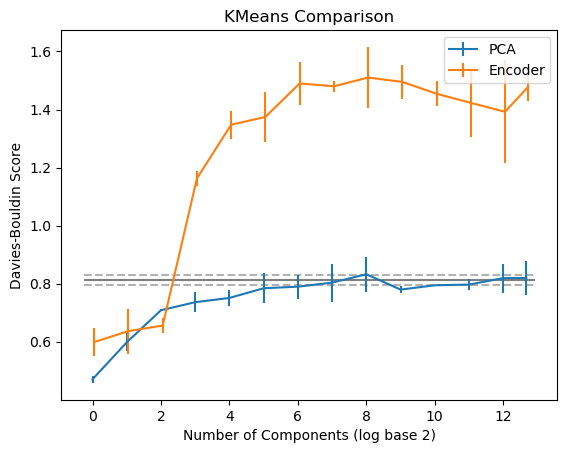

KMeans Calinksi-Harabasz Score False


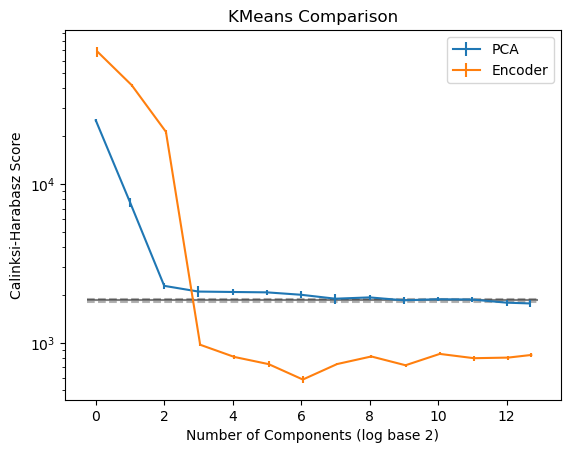

Agglomerative Rand Score True


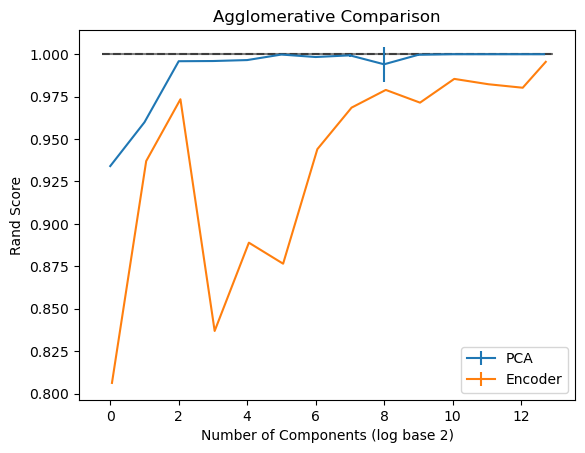

Agglomerative normalized MI Score True


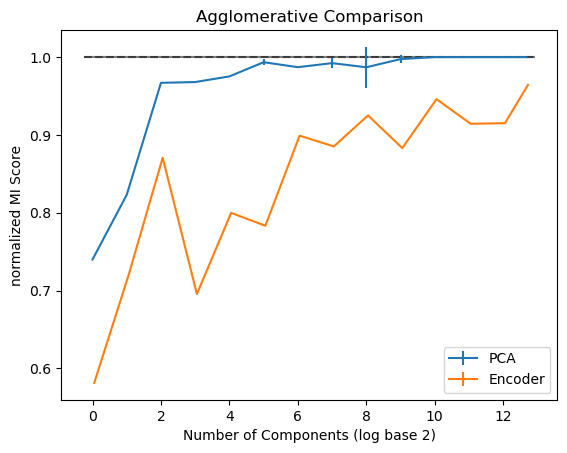

Agglomerative Fowlkes-Mallows Score True


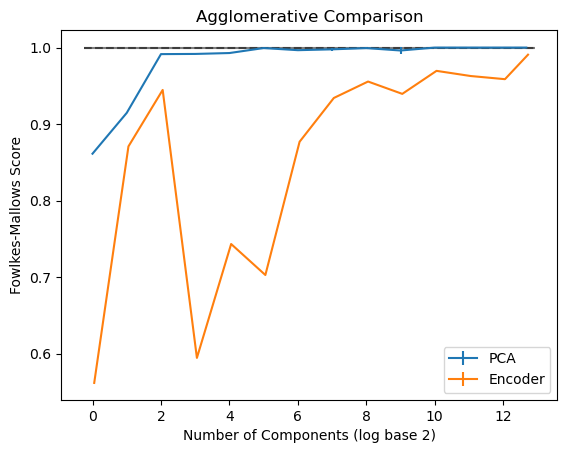

Agglomerative Silhouette Score False


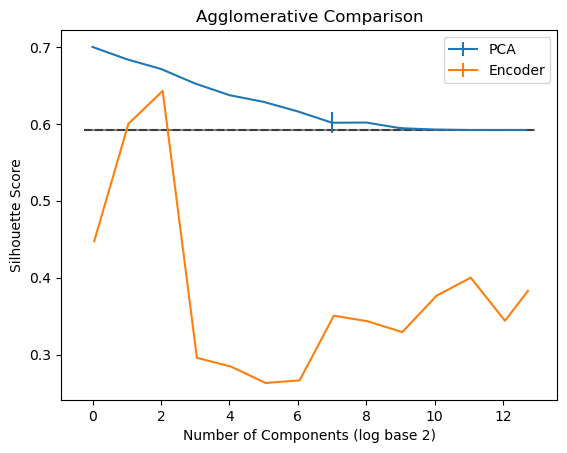

Agglomerative Davies-Bouldin Score False


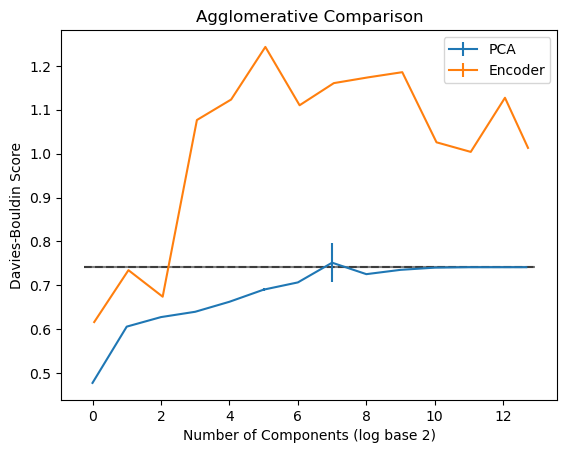

Agglomerative Calinksi-Harabasz Score False


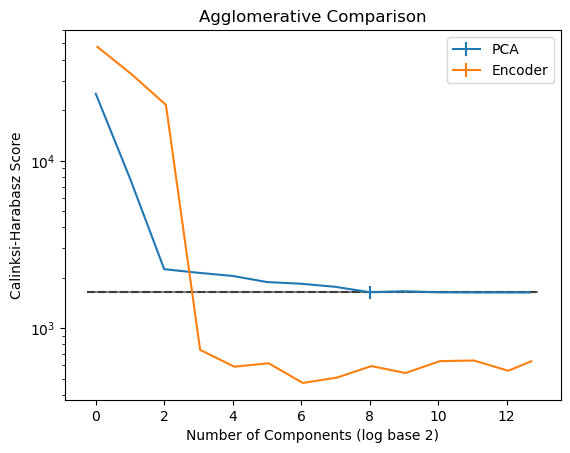

HDBScan Rand Score True


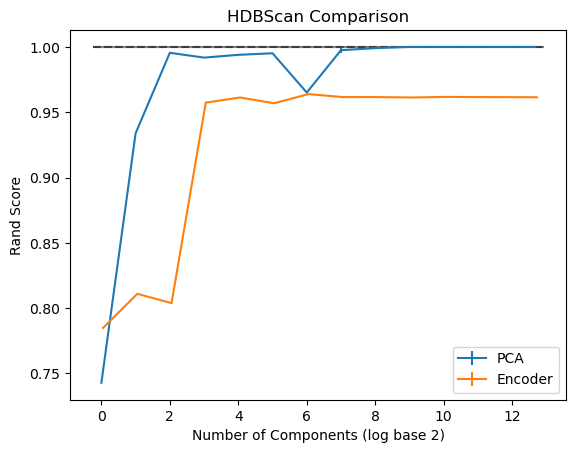

HDBScan normalized MI Score True


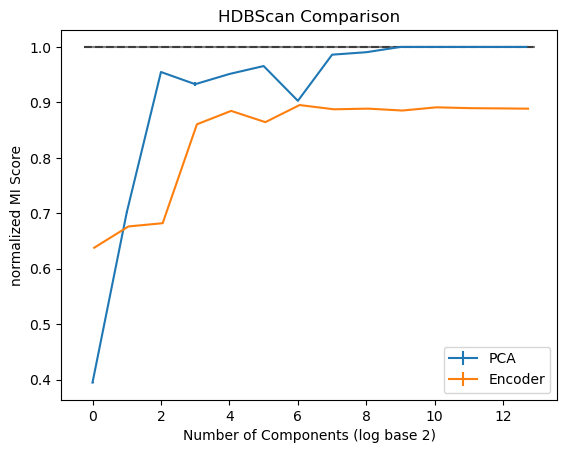

HDBScan Fowlkes-Mallows Score True


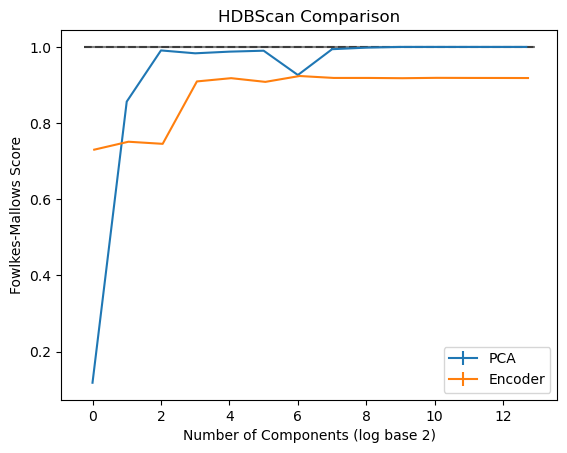

HDBScan Silhouette Score False


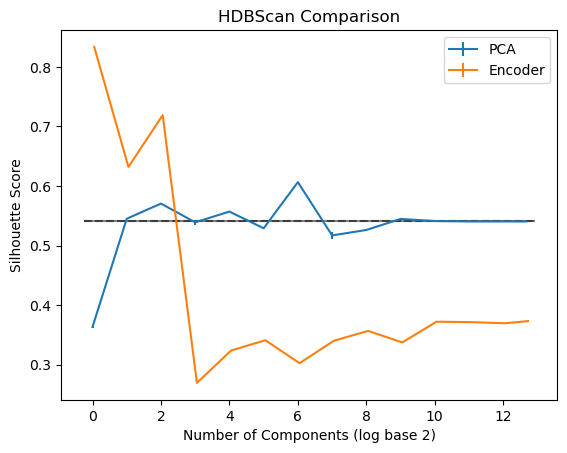

HDBScan Davies-Bouldin Score False


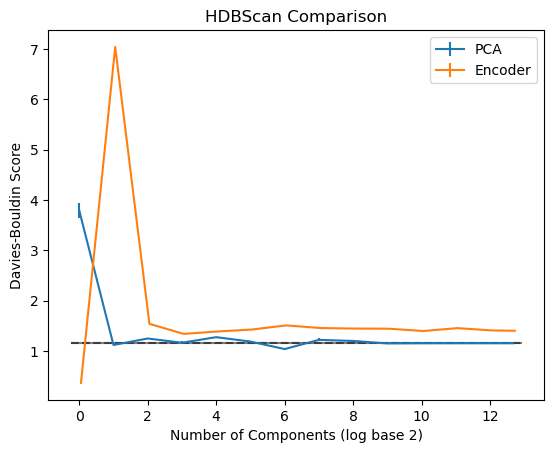

HDBScan Calinksi-Harabasz Score False


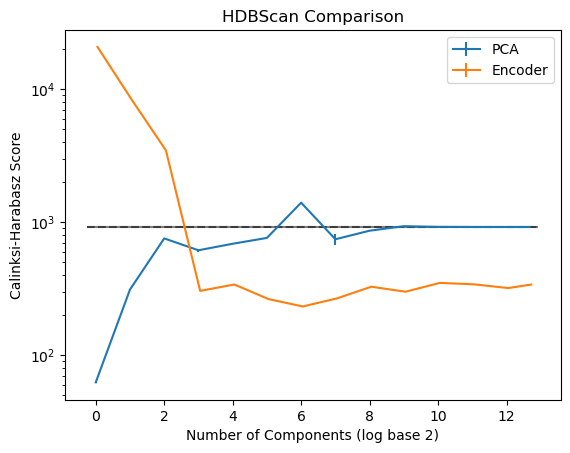

In [19]:
for method_name in clustering_methods.keys():
    n_clusters = optimal_nums_clusters[method_name]
    
    for metric_name, metric in metric_functions.items():
        metric_function, is_supervised = metric
        print(method_name, metric_name, is_supervised)
        #Run repeated clusterings on the test data
        validation_y, validation_y_err = validation_value(n_clusters=n_clusters,
                                                          clustering_method=method_name,
                                                          metric_function=metric_function,
                                                          supervised=is_supervised)
        #Multiple rounds of clustering with PCA and Encoder
        domain, pca_ys, enc_ys = evaluate_pca_encoder_against_metric(n_clusters=n_clusters,
                                                                     clustering_method=method_name,
                                                                     metric_function=metric_function,
                                                                     supervised=is_supervised,
                                                                     recon_data=True)
        #Make a plot
        clustering_metric_plot(xs=domain, pcays=pca_ys, encys=enc_ys,
                               valid_y=validation_y, valid_y_err=validation_y_err,
                               n_clusters=n_clusters, title=f"{method_name} Comparison",
                               ylabel=metric_name)                       

In [20]:
raise Exception("STOP! \n Hammertime")

Exception: STOP! 
 Hammertime

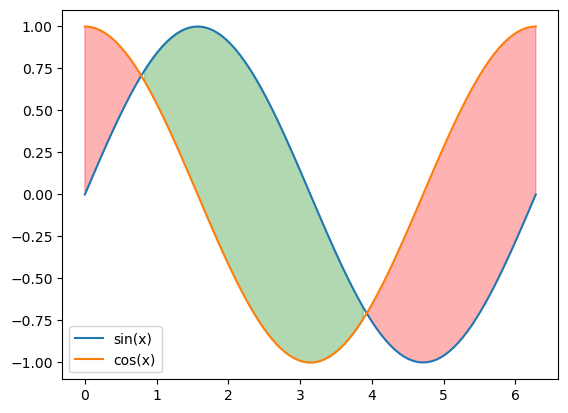

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Generate some data
x = np.linspace(0, 2 * np.pi, 100)
y1 = np.sin(x)
y2 = np.cos(x)

# Create the plot
plt.plot(x, y1, label='sin(x)')
plt.plot(x, y2, label='cos(x)')

# Fill the area between the lines
plt.fill_between(x, y1, y2, where=(y1 > y2), color='green', alpha=0.3)
plt.fill_between(x, y1, y2, where=(y1 < y2), color='red', alpha=0.3)

# Add a legend and show the plot
plt.legend()
plt.show()

#### Perform a Latent Dimension Perturbation

Using the four latent model, perturb each cluster center along each latent axis by a set quantity (0.25?)\
Save each of these perturbed coordinates

In [41]:
n_latents = 4
n_clusters = 4
perturbing_constant = 0.5
rng_seed = 2358

#Perform the kmeans clustering
labels, kmeans = self.experiments['2 Latents'].cluster_test(num_clusters=n_clusters)

#Obtain the centers
centers = kmeans.cluster_centers_
print(centers.shape)

#Encode (and decode) the centers
exp = self.experiments[f'{n_latents} Latents']
decoded, latent = exp.state.apply_fn({'params':exp.state.params}, centers, rng_seed)
print(decoded.shape, latent.shape)

#Perturb the centers along each axis by a constant
perturbed_latents = jnp.empty((n_latents * centers.shape[0], n_latents))
for center_index in range(n_clusters): #iterate over num centers
    for latent_index in range(n_latents):
        perturbed_latent_index = center_index*n_latents + latent_index
        perturbing_vector = jnp.zeros(n_latents)
        perturbing_vector = perturbing_vector.at[latent_index].set(perturbing_constant)
        perturbed_latents = perturbed_latents.at[perturbed_latent_index, :].set(latent[latent_index] + perturbing_vector)
decoded_perturbed = exp.decode(rng_seed, perturbed_latents)
print(perturbed_latents.shape, decoded_perturbed.shape)

(4, 1926)
(4, 1926) (4, 4)
(16, 4) (16, 1926)


In [42]:
#Grab the Visualization code from other branch and put it here
def create_arrow_bild_file(start_coords, end_coords, output_file, color="blue", size=0.1, shape=0.3):
    """
    Create a .bild file with arrow representations for each atom showing movement from one trajectory to another.

    Parameters:
    - start_coords (numpy array): Atomic coordinates from the first trajectory (n_atoms, 3).
    - end_coords (numpy array): Atomic coordinates from the second trajectory (n_atoms, 3).
    - output_file (str): The name of the output .bild file to be created.
    - color (str): Color of the arrows (default: "blue").
    - size (float): Size of the arrows (default: 0.1).
    - shape (float): Shape of the arrows (default: 0.3).
    """
    with open(output_file, 'w') as bild_file:
        for start, end in zip(start_coords, end_coords):
            arrow_line = f".color {color}\n" \
                         f".arrow {start[0] * 10} {start[1] * 10} {start[2] * 10} " \
                         f"{end[0] * 10} {end[1] * 10} {end[2] * 10} {size} {shape}\n"
            bild_file.write(arrow_line)

In [43]:
#Specify the directory to store these files and the colors of different latents
bild_file_directory = f"perturbation/{system.replace(' ','_')}_bild_files"
if not os.path.isdir(bild_file_directory):
    os.mkdir(bild_file_directory)

#Latent 0, 1, 2, 3
cmap = ['magenta', 'cyan', 'green', 'orange']

In [44]:
#Write the bild files
for i, decoded_center_frame in enumerate(decoded):
    perturbed_decoded_indices = (i*n_latents, i*n_latents + n_latents)
    perturbed_decoded_frames = decoded_perturbed[perturbed_decoded_indices[0]:perturbed_decoded_indices[1]]
    for j, perturbed_decoded_frame in enumerate(perturbed_decoded_frames):
        #print(i, j, decoded_center_frame.reshape(-1, 3).shape, perturbed_decoded_frame.reshape(-1, 3).shape)
        bild_file_fn = os.path.join(bild_file_directory, f'{system.replace(' ', '_')}_{n_clusters}clusters_center{i}_latent{j}.bild')
        create_arrow_bild_file(start_coords=decoded_center_frame.reshape(-1, 3),
                               end_coords=perturbed_decoded_frame.reshape(-1, 3),
                               output_file=bild_file_fn,
                               color=cmap[j])

In [45]:
from openmm.app import AmberPrmtopFile, PDBFile
#Write out the coordinates to a trajectory
def write_pdb_file(prmtop, positions_vec, pdbfile_fn):
    if positions_vec.shape[-1] != 3:
        positions = positions_vec.reshape(-1, 3)
    else:
        positions = positions_vec
    
    with open(pdbfile_fn, 'w') as f:
        PDBFile.writeModel(prmtop.topology, positions*10, file=f)
    return None

In [46]:
structure_file_directory = f"perturbation/{system.replace(' ','_')}_structures"
if not os.path.isdir(structure_file_directory):
    os.mkdir(structure_file_directory)

In [47]:
# CHANGE ME IF NECESSARY
prmtop = AmberPrmtopFile('Simulation/1crn_H.prmtop') #CHANGE ME IF NECESSARY
# CHANGE ABOVE IF NECESSARY

for i, decoded_center_frame in enumerate(decoded):
    write_pdb_file(prmtop,
                   decoded_center_frame,
                   os.path.join(structure_file_directory, f"{system.replace(' ', '_')}_decoded_center{i}.pdb"))
    perturbed_decoded_indices = (i*n_latents, i*n_latents + n_latents)
    perturbed_decoded_frames = decoded_perturbed[perturbed_decoded_indices[0]:perturbed_decoded_indices[1]]
    for j, perturbed_decoded_frame in enumerate(perturbed_decoded_frames):
        write_pdb_file(prmtop,
                       perturbed_decoded_frame,
                       os.path.join(structure_file_directory, f"{system.replace(' ', '_')}_decoded_center{i}_perturbed{j}.pdb"))
        


In [ ]:
np.log2(np.array((132, 306, 1926, 6531, 9897)))

In [ ]:
lsize = [16, 64, 512, 512, 2048]
fsize = [132, 306, 1926, 6531, 9897]
for i in range(5):
    print(100*lsize[i]/fsize[i])

In [ ]:
exp = self.experiments['4 Latents']

In [ ]:
rng_seed = 28507

recon, latents = exp.operate(rng_seed)

In [ ]:
latents.shape, recon.shape

In [ ]:
for i in range(latents.shape[-1]):
    plt.clf()
    _ = plt.hist(latents[:, i], bins=100)
    plt.show()

In [ ]:
#How much does a perturbation of latent change the atomistic position?
latent_domain_sizes = [np.max(latents[:, i]) - np.min(latents[:, i]) for i in range(latents.shape[-1])]
print(latent_domain_sizes)

In [ ]:
np.sum(np.logspace(-2, 0, 101))

In [ ]:
ave_shifts = np.zeros((102,4))

for i in range(4):
    perturbed = latents.at[:, i].add(latent_domain_sizes[i]/10)
    perturbed_recon = exp.decode(rng_seed, perturbed)
    diff_recon = perturbed_recon - recon
    diff_recon = diff_recon.reshape(diff_recon.shape[0], -1, 3)
    Edist = np.sqrt(np.sum(diff_recon**2, axis=2))
    mean_edist = np.mean(Edist, axis=0)
    ave_shifts[:, i] = mean_edist
    print(mean_edist.shape)
    plt.clf()
    _ = plt.figure(figsize=(6.4, 3), dpi=300)
    _ = plt.bar(np.arange(1, 103), mean_edist*10)
    plt.rc('font', **{'weight':'normal', 'size':11})
    plt.title(f'Latent {i+1}')
    plt.xlabel('Atom Index')
    plt.ylabel('Positional Change (Angstrom)')
    plt.savefig(f'DA-4Latents-SuPoL{i+1}.png', dpi=600, bbox_inches = "tight")
    plt.show()
    

In [ ]:
import mdtraj as md

In [ ]:
traj = md.load('Simulation/ala_deca_peptide.pdb')

In [ ]:
i = 0
for atom in traj.top.atoms:
    print(i, atom, atom.is_backbone, *ave_shifts[i, :])
    i += 1

In [ ]:
self.potential_violin_plot(rng_seed=98263, title='Potential Energy Error upon Reconstruction - DecaAlanine')

In [ ]:
model = self.experiments['4 Latents']
rng_seed = 92183

In [ ]:
test_data = model.test_data
recon, _ = model.operate(rng_seed)
_, samples_5 = model.gaussian_mm_fit(rng_seed, 5)

In [ ]:
test_ener = gas_fun(test_data)
recon_ener = gas_fun(recon)
ener_5 = gas_fun(model.decode(rng_seed, samples_5))

In [ ]:
plt.clf()
plt.figure(figsize=(3.25, 3))
threshold = 1e3
plt.hist(test_ener, histtype='step', bins=25, density=True)

num_outliers_recon = recon_ener[recon_ener > threshold].shape[0]
print(f"Outliers above {threshold} kJ/mol for 4 Latents - 5 Components: {num_outliers_recon} ({100*num_outliers_recon/2000} %)")
plt.hist(recon_ener[recon_ener < threshold], histtype='step', bins=25, density=True)

num_outliers_5 = ener_5[ener_5 > threshold].shape[0]
print(f"Outliers above {threshold} kJ/mol for 4 Latents - 5 Components: {num_outliers_5} ({100*num_outliers_5/2000} %)")
plt.hist(ener_5[ener_5 < threshold], histtype='step', bins=25, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(['Original', 'Reconstructed', 'Gaussian MM'])
plt.ylabel('Density')
plt.savefig(f'DA_4_latents_GMM_ener.png', dpi=600, bbox_inches = "tight")
plt.show()

In [ ]:
test, decoded, generated = model.test_decoded_modeled_trajs(rng_seed, 5)

In [ ]:
#Cluster the generated
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
clusters = []
for i in range(2, 10):
    clusters.append(i)
    kmeans = KMeans(n_clusters=i).fit_predict(generated)
    sil_scores.append(silhouette_score(generated, kmeans))

sil_scores = np.array(sil_scores)
clusters = np.array(clusters)


plt.clf()
_ = plt.plot(clusters, sil_scores)
plt.xlabel('Num Clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(generated)

In [ ]:
plt.clf()
_ = plt.hist(jnp.log10(gas_fun(generated)), bins=25, histtype='step', density=True)
_ = plt.hist(jnp.log10(gas_fun(test)), bins=25, histtype='step', density=True)
plt.show()

gas_fun(kmeans.cluster_centers_)

In [ ]:
model = self.experiments['16 Latents']

In [ ]:
variance = lambda x: jnp.sum((x - jnp.mean(x))**2)/x.shape[0]
std_dev = lambda x: jnp.sqrt(variance(x))

def divvy_pdevs(pdevs, n_move):
    return jnp.array([pdevs[i-n_move:i] for i in range(n_move, pdevs.shape[0])])

def calculate_variance_of_pdev(pdevs, n_move):
    pdevs_div = divvy_pdevs(pdevs, n_move)
    return jax.vmap(variance, in_axes=(0))(pdevs_div)

def calculate_stddev_of_pdev(pdevs, n_move):
    pdevs_div = divvy_pdevs(pdevs, n_move)
    return jax.vmap(std_dev, in_axes=(0))(pdevs_div)

In [ ]:
n_move = 100

for key, exp in self.experiments.items():
    print(key, exp)
    pdevs_train = jnp.mean(np.array(exp.rootgrp['Train'].variables['Potential']), axis=1)
    pdevs_test = jnp.mean(np.array(exp.rootgrp['Test'].variables['Potential']), axis=1)
    vars_train = calculate_stddev_of_pdev(pdevs_train, n_move)
    vars_test = calculate_stddev_of_pdev(pdevs_test, n_move)

    plt.clf()
    _ = plt.plot(jnp.arange(n_move, vars_train.shape[0] + n_move), vars_train)
    _ = plt.plot(jnp.arange(n_move, vars_test.shape[0] + n_move), vars_test)
    plt.title(key)
    plt.ylabel('Std Dev of Potential Deviation')
    plt.legend(['Train', 'Test'])
    plt.xlabel('Epoch')
    plt.yscale('log')
    plt.savefig(f'std_dev_of_potential_deviation_{key}.png')
    plt.show()    

In [ ]:
n_move = 10

for key, exp in self.experiments.items():
    print(key, exp)
    pdevs_train = jnp.mean(np.array(exp.rootgrp['Train'].variables['Potential']), axis=1)
    pdevs_test = jnp.mean(np.array(exp.rootgrp['Test'].variables['Potential']), axis=1)
    vars_train = calculate_stddev_of_pdev(pdevs_train, n_move)
    vars_test = calculate_stddev_of_pdev(pdevs_test, n_move)

    plt.clf()
    _ = plt.plot(jnp.arange(n_move, vars_train.shape[0] + n_move), vars_train)
    _ = plt.plot(jnp.arange(n_move, vars_test.shape[0] + n_move), vars_test)
    plt.title(key)
    plt.ylabel('Std Dev of Potential Deviation')
    plt.xlabel('Epoch')
    plt.yscale('log')
    plt.show()

In [ ]:
plt.clf()
_ = plt.plot(jnp.arange(100, vars.shape[0]+100), jnp.sqrt(vars))
plt.yscale('log')
plt.show()

In [ ]:
fname = f'{model.model_name}{model.n_latents:04d}_GMM_sample_cluster_centers.dcd'
traj_xyz = kmeans.cluster_centers_.reshape(kmeans.cluster_centers_.shape[0], -1, 3)
with md.formats.DCDTrajectoryFile(fname, 'w') as f:
    f.write(traj_xyz*10)

In [ ]:
#Single Digits Latents
plt.clf()
n_latents = 10
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=25, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items() if exp.n_latents < n_latents and exp.n_latents > n_latents/10]
for key, exp in self.experiments.items():
    if exp.n_latents < n_latents and exp.n_latents > n_latents/10:
        recon, _ = exp.operate(rng_seed)
        potentials = gas_fun(recon)
        num_outliers = potentials[potentials > threshold].shape[0]
        print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
        plt.hist(potentials[potentials < threshold], histtype='step', bins=25, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

In [ ]:
#Double Digits Latents
plt.clf()
n_latents = 100
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=100, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items() if exp.n_latents < n_latents and exp.n_latents > n_latents/10]
for key, exp in self.experiments.items():
    if exp.n_latents < n_latents and exp.n_latents > n_latents/10:
        recon, _ = exp.operate(rng_seed)
        potentials = gas_fun(recon)
        num_outliers = potentials[potentials > threshold].shape[0]
        print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
        plt.hist(potentials[potentials < threshold], histtype='step', bins=100, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

In [ ]:
#Triple Digits Latents
plt.clf()
n_latents = 1000
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=100, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items() if exp.n_latents < n_latents and exp.n_latents > n_latents/10]
for key, exp in self.experiments.items():
    if exp.n_latents < n_latents and exp.n_latents > n_latents/10:
        recon, _ = exp.operate(rng_seed)
        potentials = gas_fun(recon)
        num_outliers = potentials[potentials > threshold].shape[0]
        print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
        plt.hist(potentials[potentials < threshold], histtype='step', bins=100, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

In [ ]:
#Single Digits Latents
plt.clf()
n_latents = 10
rng_seed = 92183
threshold = 1e3
test_data = self.experiments['2 Latents'].test_data
plt.hist(gas_fun(test_data), histtype='step', bins=25, density=True)
legend_elements = ['TEST'] + [key for key, exp in self.experiments.items() if exp.n_latents < n_latents and exp.n_latents > n_latents/10]
for key, exp in self.experiments.items():
    if exp.n_latents < n_latents and exp.n_latents > n_latents/10:
        _, samples = exp.gaussian_mm_fit(rng_seed, 5)
        recon = exp.decode(rng_seed, samples)
        potentials = gas_fun(recon)
        num_outliers = potentials[potentials > threshold].shape[0]
        print(f"Outliers above {threshold} kJ/mol for {key}: {num_outliers} ({100*num_outliers/2000} %)")
        plt.hist(potentials[potentials < threshold], histtype='step', bins=25, density=True)

plt.xlabel('Energy (kJ/mol)')
plt.legend(legend_elements)
plt.show()

In [ ]:
A, B = self.super_traj_construct()

In [ ]:
rmsd = jax.vmap(atom_rmsd)(A, B)

In [ ]:
plt.clf()
_ = plt.plot(jnp.arange(rmsd.shape[0]), rmsd*10)
plt.vlines(jnp.array((500,1000,1500,2000,2500,3000,3500,4000)), jnp.array([0.025]*8), jnp.array([2.5]*8), colors='r')
plt.ylabel('RMSD (A)')
plt.ylim(0.1, 2)
plt.show()

In [ ]:
def write_traj(fname, traj_xyz): #(n conf, n_atoms*3) OR (n conf, n_atoms, 3)
    if traj_xyz.shape[-1] != 3:
        traj_xyz = traj_xyz.reshape(traj_xyz.shape[0], -1, 3)
    
    with md.formats.DCDTrajectoryFile(fname, 'w') as f:
        f.write(traj_xyz*10) #*10 because mdtraj loads data in nm but writes it as angstrom (charmdcd standard is angstrom)

In [ ]:
write_traj('Test_Data_Super.dcd', A)
write_traj('Decoded_Data_Super.dcd', B)

In [ ]:
#Write a PDB for visualization with OpenMM

In [ ]:
from openmm import *
from openmm.app import *
from openmm.unit import *

In [ ]:
prmtop = AmberPrmtopFile('Simulation/1crn_H.prmtop')
positions = A[0, :].reshape(-1, 3)
with open('1crn_H.pdb', 'w') as f:
    PDBFile.writeModel(prmtop.topology, positions*10, file=f)